In [0]:
%run ./00_configuracion

Configuración cargada correctamente.
Ruta base: /Volumes/workspace/default/tcga_cancer_ml
Número de clases oficiales: 18


Estructura creada correctamente:
/Volumes/workspace/default/tcga_cancer_ml
/Volumes/workspace/default/tcga_cancer_ml/raw
/Volumes/workspace/default/tcga_cancer_ml/trusted
/Volumes/workspace/default/tcga_cancer_ml/refined
/Volumes/workspace/default/tcga_cancer_ml/models
/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq
/Volumes/workspace/default/tcga_cancer_ml/raw/metadata
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_long
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_matrix
/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs
/Volumes/workspace/default/tcga_cancer_ml/refined/model_metrics
/Volumes/workspace/default/tcga_cancer_ml/refined/predictions
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations


muestras_unicas_long,filas_samples,muestras_unicas_samples,pacientes_unicos_long,genes_unicos_long
8335,8335,8335,8283,19944


## Configuración general

In [0]:
# 05_aplicacion_visualizacion_refined
# Capa de aplicación / visualización conectada a la zona refined del datalake

from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Asegurar carpeta de salidas visuales de aplicación
dbutils.fs.mkdirs(REFINED_VISUALIZATIONS_PATH)

print("Leyendo tablas refined desde Unity Catalog...")

TABLA_CONTEO_CLASES = "workspace.default.refined_eda_conteo_clases"
TABLA_DESBALANCE = "workspace.default.refined_eda_desbalance_clases"
TABLA_EXPRESION = "workspace.default.refined_eda_expresion_global"
TABLA_GENES_VAR = "workspace.default.refined_eda_genes_mas_variables"
TABLA_METRICAS = "workspace.default.refined_metricas_modelos_sparkml"
TABLA_REPORTE_CLASE = "workspace.default.refined_reporte_clasificacion_por_clase"
TABLA_CONFUSION = "workspace.default.refined_matriz_confusion_mejor_modelo"
TABLA_PREDICCIONES = "workspace.default.refined_predicciones_test_mejor_modelo"

df_clases = spark.table(TABLA_CONTEO_CLASES)
df_desbalance = spark.table(TABLA_DESBALANCE)
df_expr = spark.table(TABLA_EXPRESION)
df_genes_var = spark.table(TABLA_GENES_VAR)
df_metricas = spark.table(TABLA_METRICAS)
df_reporte = spark.table(TABLA_REPORTE_CLASE)
df_confusion = spark.table(TABLA_CONFUSION)
df_pred = spark.table(TABLA_PREDICCIONES)

print("Tablas cargadas correctamente.")

Leyendo tablas refined desde Unity Catalog...
Tablas cargadas correctamente.


## 1. Resumen general

In [0]:
# 1. Resumen general
print("Resumen de tablas disponibles en refined:")
print("Conteo clases:", df_clases.count())
print("Desbalance:", df_desbalance.count())
print("Expresión global:", df_expr.count())
print("Genes variables:", df_genes_var.count())
print("Métricas de modelos:", df_metricas.count())
print("Reporte por clase:", df_reporte.count())
print("Matriz de confusión:", df_confusion.count())
print("Predicciones test:", df_pred.count())

display(df_metricas.orderBy("split", F.desc("f1_macro")))

Resumen de tablas disponibles en refined:
Conteo clases: 18
Desbalance: 18
Expresión global: 18
Genes variables: 5000
Métricas de modelos: 9
Reporte por clase: 21
Matriz de confusión: 324
Predicciones test: 1257


modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro_ovr,gap_f1_macro_train_validation,gap_accuracy_train_validation
RandomForestClassifier,test,0.8973747016706444,0.8769406843175944,0.8953954105814819,0.8769406843175944,0.8755922799373392,0.9011834556529016,0.8973747016706444,0.8918567474838998,null,null,0.05848239760240492,0.04611557995881943
NaiveBayes,test,0.8750994431185362,0.8663119524600494,0.8707619017817603,0.8663119524600494,0.8653495748050761,0.8882848723768865,0.8750994431185362,0.8789868142035887,0.9904518634199112,0.9097940913224788,0.013673611030621036,0.013842141386410378
LogisticRegression_multinomial,test,0.8894192521877486,0.8544005196808331,0.8942557396612723,0.8544005196808331,0.8637171881157416,0.8945114186062314,0.8894192521877486,0.8849338067025935,null,null,0.01500548849075145,0.013857515442690427
RandomForestClassifier,train,0.9389155799588195,0.9197660716563326,0.9472562358820572,0.9197660716563326,0.9253142131240318,0.9447692554990648,0.9389155799588195,0.9359279568144045,null,null,0.05848239760240492,0.04611557995881943
LogisticRegression_multinomial,train,0.9066575154426905,0.8720229515009823,0.911369691728066,0.8720229515009823,0.8830417138308841,0.9116354817569962,0.9066575154426905,0.9029967855766412,null,null,0.01500548849075145,0.013857515442690427
NaiveBayes,train,0.8898421413864104,0.87906294372492,0.8844365586946997,0.87906294372492,0.8796043829138112,0.8968784935957458,0.8898421413864104,0.8912466183116245,0.9917999387849376,0.9210663322531967,0.013673611030621036,0.013842141386410378
LogisticRegression_multinomial,validation,0.8928,0.8558824536226768,0.9001702746934777,0.8558824536226768,0.8680362253401327,0.8992669420007845,0.8928,0.8890673514628347,null,null,0.01500548849075145,0.013857515442690427
RandomForestClassifier,validation,0.8928,0.863808314567591,0.893365685704399,0.863808314567591,0.8668318155216269,0.895958531432549,0.8928,0.8858791813943854,null,null,0.05848239760240492,0.04611557995881943
NaiveBayes,validation,0.876,0.8700180356857727,0.8662402761280753,0.8700180356857727,0.8659307718831901,0.8863677573936584,0.876,0.8790182111784365,0.9893141115796534,0.9011377110027544,0.013673611030621036,0.013842141386410378


## 2. Distribución de clases

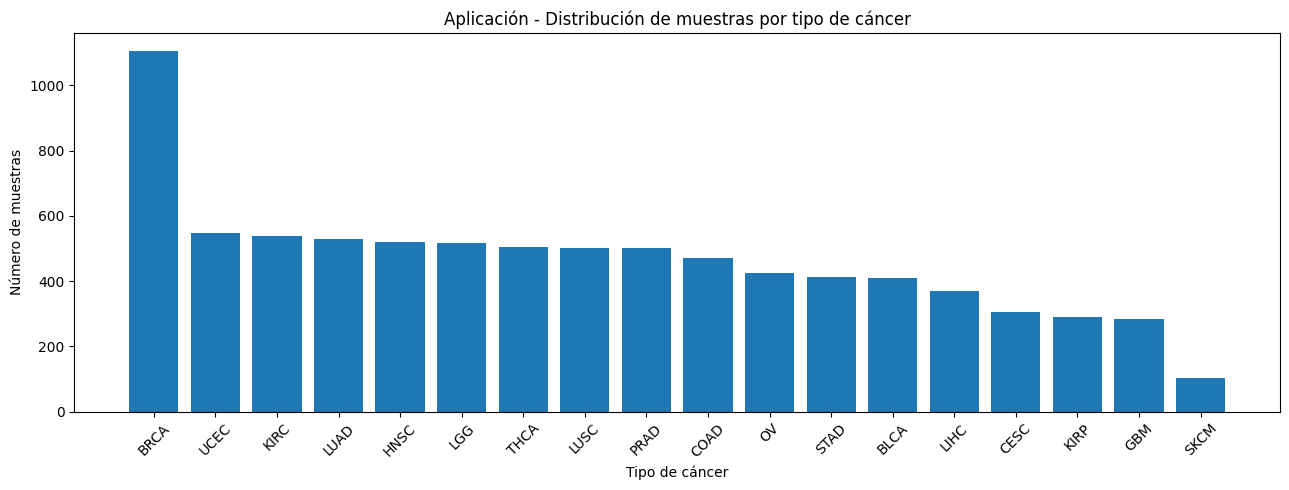

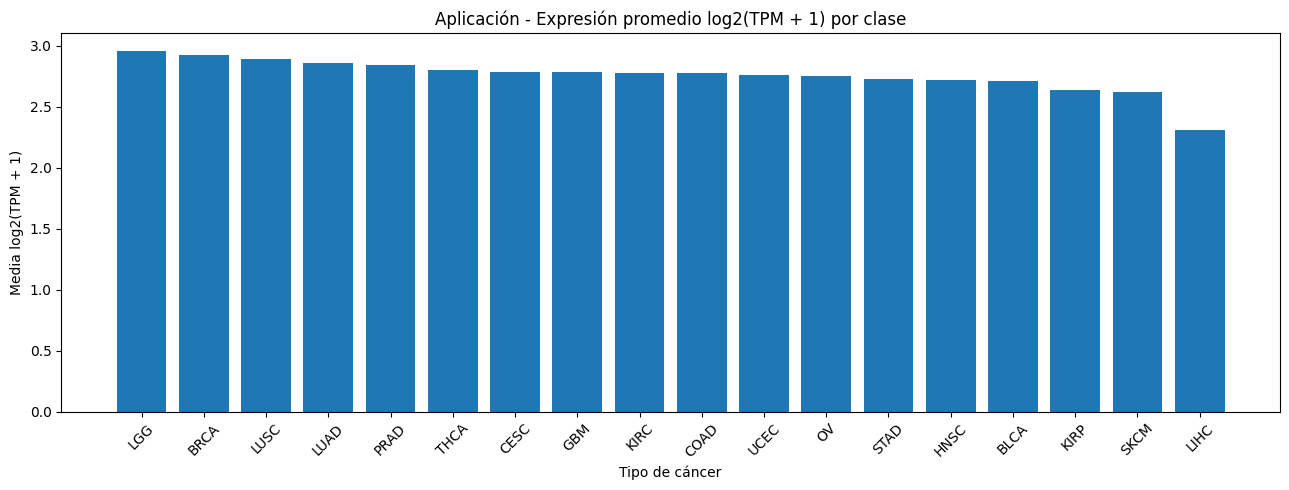

Gráficos guardados en:
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_distribucion_clases.png
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_expresion_promedio.png


In [0]:
# 2. Distribución de clases

pdf_clases = df_clases.toPandas().sort_values("n_muestras", ascending=False)
pdf_expr = df_expr.toPandas().sort_values("media_log2_tpm", ascending=False)

plt.figure(figsize=(13, 5))
plt.bar(pdf_clases["cancer_type"], pdf_clases["n_muestras"])
plt.title("Aplicación - Distribución de muestras por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45)
plt.tight_layout()

ruta_1 = f"{REFINED_VISUALIZATIONS_PATH}/app_distribucion_clases.png"
plt.savefig(ruta_1, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(13, 5))
plt.bar(pdf_expr["cancer_type"], pdf_expr["media_log2_tpm"])
plt.title("Aplicación - Expresión promedio log2(TPM + 1) por clase")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Media log2(TPM + 1)")
plt.xticks(rotation=45)
plt.tight_layout()

ruta_2 = f"{REFINED_VISUALIZATIONS_PATH}/app_expresion_promedio.png"
plt.savefig(ruta_2, dpi=300, bbox_inches="tight")
plt.show()

print("Gráficos guardados en:")
print(ruta_1)
print(ruta_2)

## 3. Comparación de modelos

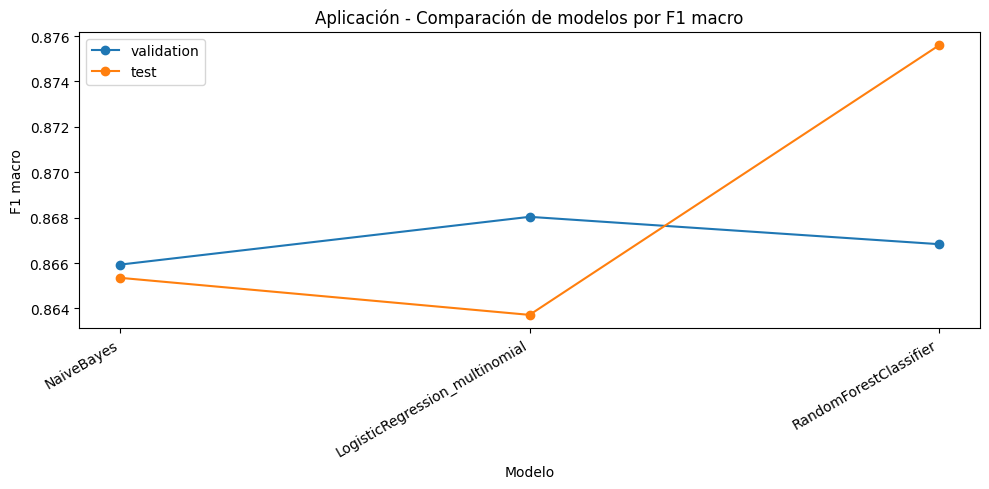

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_comparacion_modelos_f1.png


In [0]:
# 3. Comparación de modelos en validación y test

pdf_metricas = df_metricas.toPandas()
pdf_metricas = pdf_metricas[pdf_metricas["split"].isin(["validation", "test"])].copy()

plt.figure(figsize=(10, 5))
for split in ["validation", "test"]:
    temp = pdf_metricas[pdf_metricas["split"] == split]
    plt.plot(temp["modelo"], temp["f1_macro"], marker="o", label=split)

plt.title("Aplicación - Comparación de modelos por F1 macro")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()

ruta_3 = f"{REFINED_VISUALIZATIONS_PATH}/app_comparacion_modelos_f1.png"
plt.savefig(ruta_3, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_3)

## 4. Top genes más variables

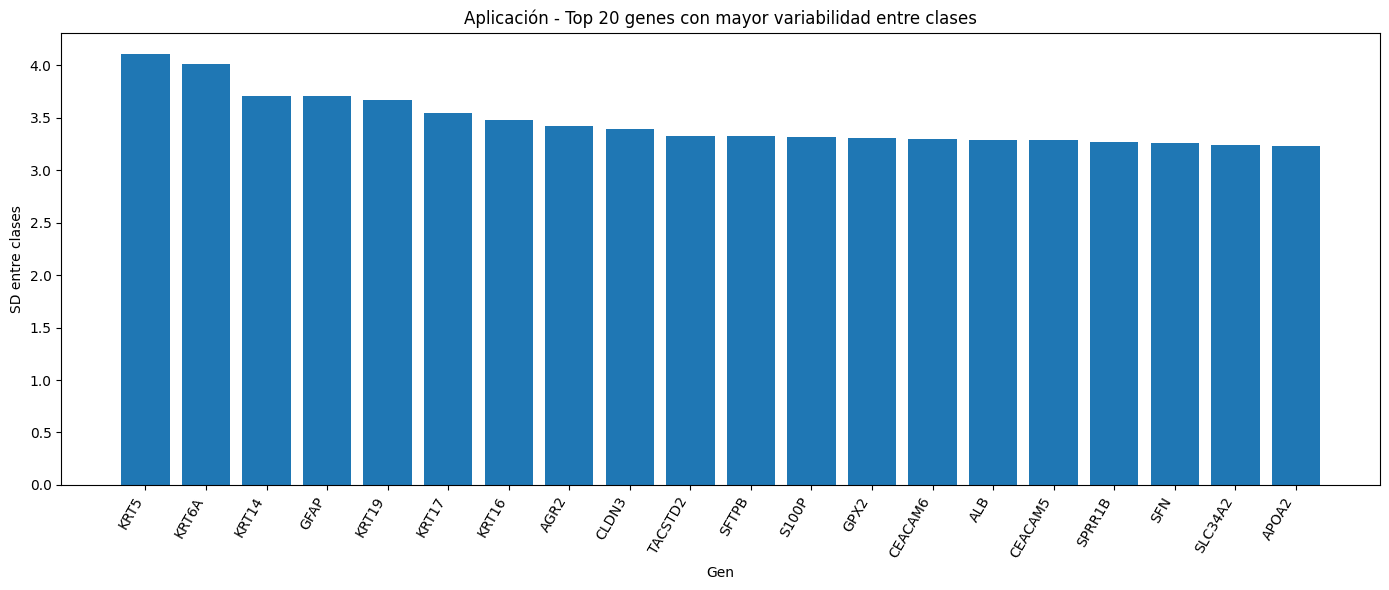

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_top20_genes_variables.png


In [0]:
# 4. Top genes más variables entre clases

pdf_genes = df_genes_var.limit(20).toPandas()

plt.figure(figsize=(14, 6))
plt.bar(pdf_genes["gene_name"], pdf_genes["sd_entre_clases"])
plt.title("Aplicación - Top 20 genes con mayor variabilidad entre clases")
plt.xlabel("Gen")
plt.ylabel("SD entre clases")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

ruta_4 = f"{REFINED_VISUALIZATIONS_PATH}/app_top20_genes_variables.png"
plt.savefig(ruta_4, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_4)

## 5. Desempeño por clase

clase,precision,recall,f1-score,support
THCA,1.0,1.0,1.0,76.0
PRAD,1.0,1.0,1.0,75.0
LIHC,0.9821428571428571,0.9821428571428571,0.9821428571428571,56.0
BRCA,0.9647058823529412,0.9820359281437125,0.973293768545994,167.0
LUAD,0.9493670886075949,0.9493670886075949,0.9493670886075949,79.0
COAD,0.8765432098765432,0.9861111111111112,0.9281045751633987,72.0
LUSC,0.9692307692307692,0.8289473684210527,0.8936170212765957,76.0
OV,0.8450704225352113,0.9375,0.8888888888888888,64.0
STAD,0.9,0.8709677419354839,0.8852459016393442,62.0
LGG,0.7938144329896907,0.9871794871794872,0.88,78.0


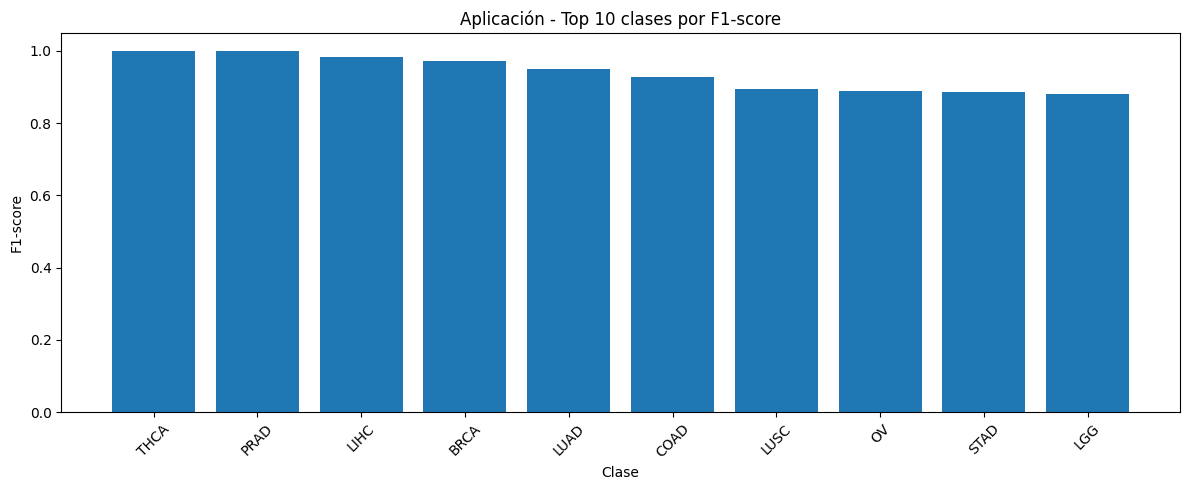

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_top10_f1_por_clase.png


In [0]:
# 5. Mostrar desempeño por clase del mejor modelo

pdf_reporte = df_reporte.toPandas().copy()

# Filtrar filas agregadas de sklearn si existen
filas_excluir = {"accuracy", "macro avg", "weighted avg"}
if "clase" in pdf_reporte.columns:
    pdf_reporte_plot = pdf_reporte[~pdf_reporte["clase"].isin(filas_excluir)].copy()
else:
    pdf_reporte_plot = pdf_reporte.copy()

# Tomar top 10 por f1-score si existe la columna
if "f1-score" in pdf_reporte_plot.columns:
    pdf_reporte_plot = pdf_reporte_plot.sort_values("f1-score", ascending=False).head(10)

display(spark.createDataFrame(pdf_reporte_plot))

if "clase" in pdf_reporte_plot.columns and "f1-score" in pdf_reporte_plot.columns:
    plt.figure(figsize=(12, 5))
    plt.bar(pdf_reporte_plot["clase"], pdf_reporte_plot["f1-score"])
    plt.title("Aplicación - Top 10 clases por F1-score")
    plt.xlabel("Clase")
    plt.ylabel("F1-score")
    plt.xticks(rotation=45)
    plt.tight_layout()

    ruta_5 = f"{REFINED_VISUALIZATIONS_PATH}/app_top10_f1_por_clase.png"
    plt.savefig(ruta_5, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gráfico guardado en:", ruta_5)

## 6. Matriz de confusión

true_class,BLCA,BRCA,CESC,COAD,GBM,HNSC,KIRC,KIRP,LGG,LIHC,LUAD,LUSC,OV,PRAD,SKCM,STAD,THCA,UCEC
BLCA,50,1,2,0,0,7,1,0,0,0,0,0,0,0,0,1,0,0
BRCA,0,164,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0
CESC,5,0,18,2,0,13,0,0,0,0,0,0,1,0,0,1,0,6
COAD,0,0,0,71,0,0,0,0,0,0,0,0,0,0,0,1,0,0
GBM,0,0,0,0,22,0,1,0,20,0,0,0,0,0,0,0,0,0
HNSC,2,0,4,0,0,70,1,0,0,0,0,1,0,0,0,0,0,0
KIRC,0,0,0,0,0,0,73,4,0,0,0,0,0,0,0,0,0,3
KIRP,0,0,0,0,0,0,5,37,0,0,0,0,0,0,0,0,0,2
LGG,0,0,0,0,0,0,1,0,77,0,0,0,0,0,0,0,0,0
LIHC,0,0,0,0,0,0,1,0,0,55,0,0,0,0,0,0,0,0


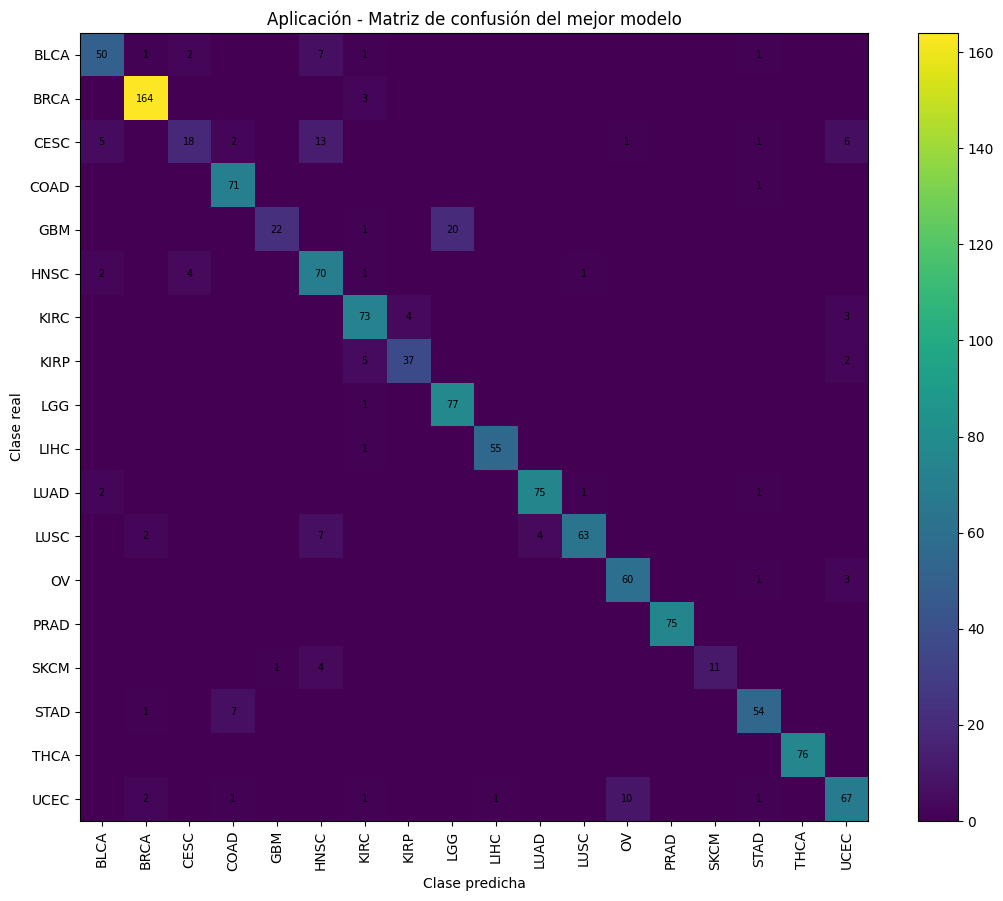

Gráfico guardado en: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/app_matriz_confusion.png


In [0]:
# 6. Matriz de confusión en formato tabla y heatmap

pdf_conf = df_confusion.toPandas()
tabla_conf = pdf_conf.pivot(index="true_class", columns="predicted_class", values="n").fillna(0)

display(spark.createDataFrame(tabla_conf.reset_index()))

plt.figure(figsize=(11, 9))
plt.imshow(tabla_conf.values, interpolation="nearest")
plt.title("Aplicación - Matriz de confusión del mejor modelo")
plt.colorbar()
plt.xticks(np.arange(len(tabla_conf.columns)), tabla_conf.columns, rotation=90)
plt.yticks(np.arange(len(tabla_conf.index)), tabla_conf.index)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

for i in range(tabla_conf.shape[0]):
    for j in range(tabla_conf.shape[1]):
        valor = int(tabla_conf.values[i, j])
        if valor > 0:
            plt.text(j, i, str(valor), ha="center", va="center", fontsize=7)

plt.tight_layout()

ruta_6 = f"{REFINED_VISUALIZATIONS_PATH}/app_matriz_confusion.png"
plt.savefig(ruta_6, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", ruta_6)

## 7. Errores más frecuentes

In [0]:
# 7. Predicciones del mejor modelo: errores más frecuentes

df_errores = (
    df_pred
    .withColumn("es_error", F.when(F.col("cancer_type") != F.col("cancer_predicho"), F.lit(1)).otherwise(F.lit(0)))
)

display(
    df_errores
    .groupBy("cancer_type", "cancer_predicho")
    .agg(F.sum("es_error").alias("n_errores"))
    .filter(F.col("n_errores") > 0)
    .orderBy(F.desc("n_errores"))
)

cancer_type,cancer_predicho,n_errores
GBM,LGG,20
CESC,HNSC,13
UCEC,OV,10
LUSC,HNSC,7
STAD,COAD,7
BLCA,HNSC,7
CESC,UCEC,6
CESC,BLCA,5
KIRP,KIRC,5
KIRC,KIRP,4


## 8. Tabla

In [0]:
# 8. Tabla

tabla_informe = (
    df_metricas
    .filter(F.col("split").isin(["validation", "test"]))
    .select(
        "modelo",
        "split",
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc_macro_ovr",
        "pr_auc_macro_ovr",
        "gap_f1_macro_train_validation"
    )
    .orderBy("split", F.desc("f1_macro"))
)

display(tabla_informe)

modelo,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,pr_auc_macro_ovr,gap_f1_macro_train_validation
RandomForestClassifier,test,0.8973747016706444,0.8769406843175944,0.8953954105814819,0.8769406843175944,0.8755922799373392,null,null,0.05848239760240492
NaiveBayes,test,0.8750994431185362,0.8663119524600494,0.8707619017817603,0.8663119524600494,0.8653495748050761,0.9904518634199112,0.9097940913224788,0.013673611030621036
LogisticRegression_multinomial,test,0.8894192521877486,0.8544005196808331,0.8942557396612723,0.8544005196808331,0.8637171881157416,null,null,0.01500548849075145
LogisticRegression_multinomial,validation,0.8928,0.8558824536226768,0.9001702746934777,0.8558824536226768,0.8680362253401327,null,null,0.01500548849075145
RandomForestClassifier,validation,0.8928,0.863808314567591,0.893365685704399,0.863808314567591,0.8668318155216269,null,null,0.05848239760240492
NaiveBayes,validation,0.876,0.8700180356857727,0.8662402761280753,0.8700180356857727,0.8659307718831901,0.9893141115796534,0.9011377110027544,0.013673611030621036


## 9. Exportación de tablas de apoyo

In [0]:
# 9. Exportar tablas ejecutivas a CSV en el Volume si se requiere evidencia externa

tabla_informe_pd = tabla_informe.toPandas()
conteo_clases_pd = df_clases.toPandas()
predicciones_pd = df_pred.toPandas().head(200)

tabla_informe_pd.to_csv("/dbfs" + f"{REFINED_VISUALIZATIONS_PATH}/app_tabla_metricas.csv", index=False)
conteo_clases_pd.to_csv("/dbfs" + f"{REFINED_VISUALIZATIONS_PATH}/app_conteo_clases.csv", index=False)
predicciones_pd.to_csv("/dbfs" + f"{REFINED_VISUALIZATIONS_PATH}/app_predicciones_muestra.csv", index=False)

print("Archivos CSV exportados correctamente a refined/visualizations.")